# **IS4487 Week 10 - Practice/Demo Code: Supervised Learning with Decision Trees**

This notebook is designed to help you follow along with the **Week 10 Lecture and Reading**, introducing you to Classification.

The practice code demos are intended to give you a chance to see working code and can be a source for your lap and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Create a classification tree
- Visualize the tree output
- Evaluate a tree

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Financial Services Marketing
We will use a classic UCI banking dataset.  Variables include:

| Feature     | Description                                          | Type        |
| ----------- | ---------------------------------------------------- | ----------- |
| `age`       | Age of the client                                    | Numeric     |
| `default`   | Has credit in default? (yes/no)                      | Categorical |
| `balance`   | Average yearly account balance in euros              | Numeric     |
| `housing`   | Has housing loan? (yes/no)                           | Categorical |
| `loan`      | Has personal loan? (yes/no)                          | Categorical |
| `y`         | Target: Subscribed to term deposit? (yes/no)         | Categorical |

Your task is to predict `y` whether a client will subscribe to a term deposit (yes/no) based on various attributes from a bank marketing campaign.  A term deposit is a fixed-timeframe investment like a CD or bond.

#**ML model: Classification Tree**

This is a decision tree used to predict a categorical outcome. This model will evaluate each feature to determine the best split and order to predict the target variable.

## **Step 1. Import libraries, load data and preview it**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset with a comma separator
url = "https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/bank_subscription.csv"
df = pd.read_csv(url, sep=',')

In [ ]:
# Preview the data
display(df.head())

# how many yes and no?
df['y'].value_counts()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,69,self-employed,divorced,secondary,no,20406,no,no,telephone,16,apr,350,7,148,7,unknown,yes
1,32,self-employed,single,secondary,no,49190,yes,no,cellular,19,jun,588,5,138,1,other,no
2,89,services,single,secondary,no,45284,yes,no,cellular,15,feb,789,3,291,2,unknown,no
3,78,unemployed,divorced,secondary,yes,43200,no,no,cellular,25,apr,263,5,117,3,unknown,no
4,38,admin.,single,tertiary,no,49002,yes,no,unknown,30,jul,659,3,245,8,failure,yes


,count
y,
yes,2250
no,2250


## **Step 2: Prepare Data**

Theoretically decision trees are able to handle both continuous and categorical inputs. However Python's version of Decision Trees cannot and requires us to convert catgeorical outcomes into numeric features using One-hot-Encoding or other encoding.

We will choose a subset of the columns to build our tree.

We will have to replace our binary features into 0/1.

In [ ]:
# Columns to use
features = ['age', 'default', 'balance', 'housing', 'loan']
target = 'y'

# Replace 'yes'/'no' with 1/0 in features and target
pd.set_option('future.no_silent_downcasting', True)
binary_cols = ['default', 'housing', 'loan', 'y']
df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})

# Features and label
X = df[features]
y = df[target]



## **Step 3: Split Dataset into Training and Testing**

We will use a built-in function from the `sklearn.model_selection` package (see import statements called `train_test_split()`.

This has a parameter `random_state` - this is needed to initialize randomization. Many ML algorithms start by first randomly setting parameter values (that they are estimating in order to do their task). random_state here decides how to pick random samples to be in train or test.

Setting  ensures reproducibility by setting a *seed* for the internal random number generator, which controls choices like which features to consider at each split when multiple options are equally good. This guarantees that running the same algorithm with the same random_state will produce the exact same tree structure and results, which is crucial for debugging, comparing models, and validating experiments.

In [ ]:
# Train/test split - 80-20
# Notice it produces 4 sub-datasets, 2 for X and corresponding two for y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Step 4: Create and Fit Model**

In the first step, we initialize a new Decision Tree. There are many things that you can customize - if you dont specify a parameter, it will use its default values.
- criterion: the purity measure to use. The default is *gini impurity*, we can change it by setting it to *entropy* to use **Information Gain**.
- max_depth: how deep a branch can be.
- random_state sets the random seed for tree building


Calling the method `DecisionTreeClassifier.fit()` will run the model, build the tree, choose the best features etc.

In [ ]:
# Intialize decision tree
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth=4, random_state=42)

# Train the model on X and y in the training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

## **Step 5: Create Visualization to View the Tree**

Notice: the tree is only 4 branches deep (since we set max_depth = 4).

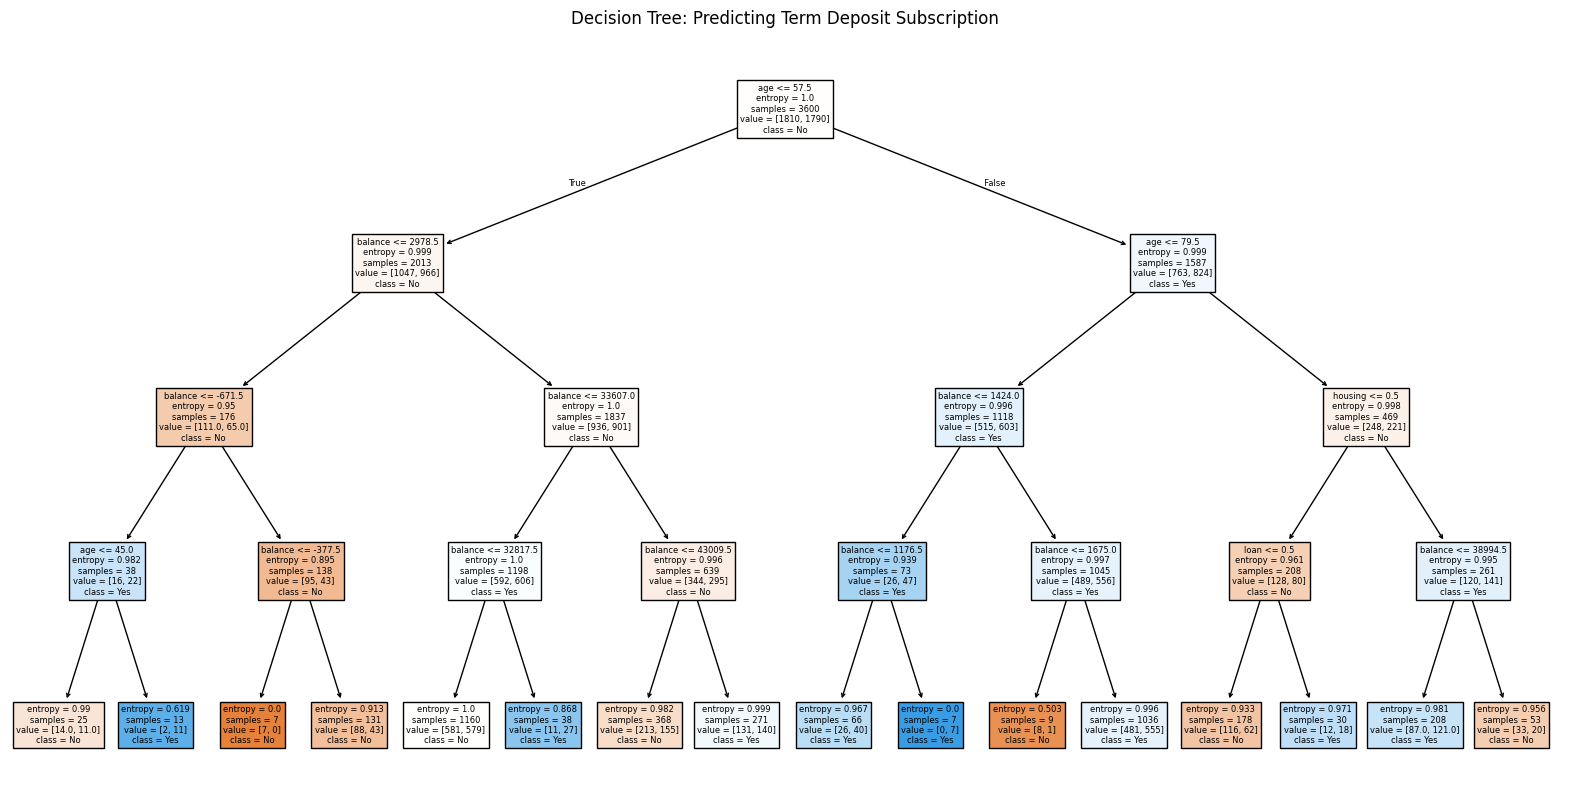

In [ ]:
# Plot decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.title("Decision Tree: Predicting Term Deposit Subscription")
plt.show()

## **Step 6: Evaluate the Tree**

Let us evaluate the model using the standard **metrics for classification**: Accuracy, Precision, Recall and F1-score for ***both training data and testing data***.

Generally, we only need to evaluate on testing data, but we will do both to understand **overfitting** and **underfitting**


In [ ]:
#### TRAINING DATA PERFORMANCE #####

# Make predictions on the training set - how well does the model predict the training data for which we have ground truth labels
y_train_pred = clf.predict(X_train)

# Calculate evaluation metrics for training data
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate evaluation metrics for testing data
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nMODEL EVALUATION: How did the model do on the test data? ")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 0.55
Precision: 0.55
Recall: 0.51
F1-score: 0.53


MODEL EVALUATION: How did the model do on the test data? 
Accuracy: 0.51
Precision: 0.52
Recall: 0.48
F1-score: 0.50


In [ ]:
# Let us print the actual and true max depth of the tree

print(f"The max_depth of the model is: {clf.get_params()['max_depth']}")
print(f"The actual depth of the tree in clf is: {clf.tree_.max_depth}")

The max_depth of the model is: 4
The actual depth of the tree in clf is: 4


### **UNDERFITTING**

Notice that our above tree does not perform well on the training data (F1-score = 0.53). Unsurprisingly, it also does not do well on the test data. We had restricted the tree to be of max depth 4.

This is a class case of **'UNDERFITTING'**

What if we remove this restriction? Let's see what happens.

## **Step 7: Compare with another tree by changing parameters**

### 7a. Try a tree with no max_depth restriction

In [ ]:
#initialize a second tree - no max_depth is specified
clf = DecisionTreeClassifier(criterion = 'entropy',  random_state=42)

# Train the model on X and y in the training data
clf.fit(X_train, y_train)

#### TRAINING DATA PERFORMANCE #####

# Make predictions on the training set
y_train_pred = clf.predict(X_train)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nHow did the model do on the test data? EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-score: 1.00


How did the model do on the test data? EVALUATION
Accuracy: 0.49
Precision: 0.50
Recall: 0.50
F1-score: 0.50


In [ ]:
print(f"The max_depth of the model is: {clf.get_params()['max_depth']}")
print(f"The actual depth of the tree in clf is: {clf.tree_.max_depth}")

The max_depth of the model is: None
The actual depth of the tree in clf is: 55


### **OVERFITTING**

**Now, what did you notice about model performance?**

The model now perfectly predicts in the training data (accuracy = 100%, F1-Score - 1.0), but continues to perform poorly in the test data (F1-score = 0.50 (compared to 0.53 before)). In fact the performance in the test data is even worse now.

This is a classic case of **'OVERFITTING'**.

The model is so deep so it perfectly predicts in training data, but is learning noise, and true underlying associations, so it does **not generalize** well to test data.


So the better model is the following:
`clf = DecisionTreeClassifier(criterion = 'entropy', max_depth=4, random_state=42)`

### 7b. Try a tree with max_depth = 5

The performance of this model is better with Accuracy 51% and F1-score 60% (better at predicting the positive class).

In [ ]:
# Initialize, and train/fit a new model
best_model = DecisionTreeClassifier(criterion = 'entropy', max_depth=5, random_state=42)
best_model.fit(X_train, y_train)

#### TRAINING DATA PERFORMANCE #####

# Make predictions on the training set
y_train_pred = best_model.predict(X_train)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")


#### MODEL EVALUATION - TESTING DATA PERFORMANCE #####

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nHow did the model do on the test data? EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 0.57
F1-score: 0.64


How did the model do on the test data? EVALUATION
Accuracy: 0.51
F1-score: 0.60


## **Step 8. Assess feature importances of the best model**

The output suggests that `balance` followed by `age` were the most important in predicting the target.

In [ ]:
print("Feature importances for best_model (max_depth=5):")
sorted_importance_clf = sorted(zip(X.columns, best_model.feature_importances_), key=lambda x: x[1], reverse=True)
for name, importance in sorted_importance_clf:
    print(f"{name}: {importance:.4f}")



Feature importances for best_model (max_depth=5):
balance: 0.4861
age: 0.3780
housing: 0.0671
loan: 0.0396
default: 0.0292


#**ML model: Ensemble methods - Random Forest**

## **Step 9: Try an ensemble model**

Let us try a Bagging Model with Trees for classification, called a Random Forest Classifier.

In [ ]:
#ensemble model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(criterion = 'entropy', n_estimators = 15, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred = rf.predict(X_train)

# Calculate evaluation metrics
accuracy = accuracy_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)

print("How did the model do on the training data?")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")


# Make predictions on the test set
y_pred = rf.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n\nHow did the model do on the test data? EVALUATION")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")

How did the model do on the training data?
Accuracy: 0.60
F1-score: 0.59


How did the model do on the test data? EVALUATION
Accuracy: 0.51
F1-score: 0.49


## Summary:

### Insights or Next Steps

*   Sometimes the models we run will not give us very good results, like the current model.
what can do next?
* Often the problem lies in the features. They are likely not the best set. You can run a correlation matrix to determine if there are better features. Then re-run the model.
* Do more feature engineering to create better features
* You can try a different ML model for classification.

